In [87]:
!pip install torch matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [88]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

vocab = ['<bos>', 'a', 'b', 'c', '<eos>']
stoi = {c: i for i, c in enumerate(vocab)}
itos = {i: c for c, i in stoi.items()}
vocab_size = len(vocab)

Task 1: Policy network

In [89]:
class CharPolicy(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: LongTensor of shape [B] holding token ids
        # returns: FloatTensor of shape [B, vocab_size] holding logits
        emb = self.embedding(x)   # [B, embed_dim]
        return self.linear(emb)   # [B, vocab_size]


Task 2: Sampling

In [90]:
def sample(model: CharPolicy, max_len: int = 8) -> tuple[list[str], torch.Tensor]:
    token = torch.tensor([stoi['<bos>']])  # [1]
    seq: list[str] = []
    log_prob_list: list[torch.Tensor] = []

    for _ in range(max_len):
        logits = model(token)                          # [1, vocab_size]
        dist = torch.distributions.Categorical(logits=logits)
        next_token = dist.sample()                     # [1]
        lp = dist.log_prob(next_token)                 # [1]

        name = itos[next_token.item()]
        seq.append(name)
        log_prob_list.append(lp)

        token = next_token.detach()
        if name == '<eos>':
            break

    log_probs = torch.cat(log_prob_list)  # [T]
    return seq, log_probs


Task 3: Reward
Implement the terminal reward

In [91]:
def reward(seq: list[str]) -> float:
    # Check if ['a', 'b', 'c'] appears as a contiguous subsequence anywhere in seq
    target = ['a', 'b', 'c']
    for i in range(len(seq) - 2):
        if seq[i:i + 3] == target:
            return 1.0
    return 0.0

Task 4: REINFORCE update (no baseline)

In [92]:
epochs = 1500

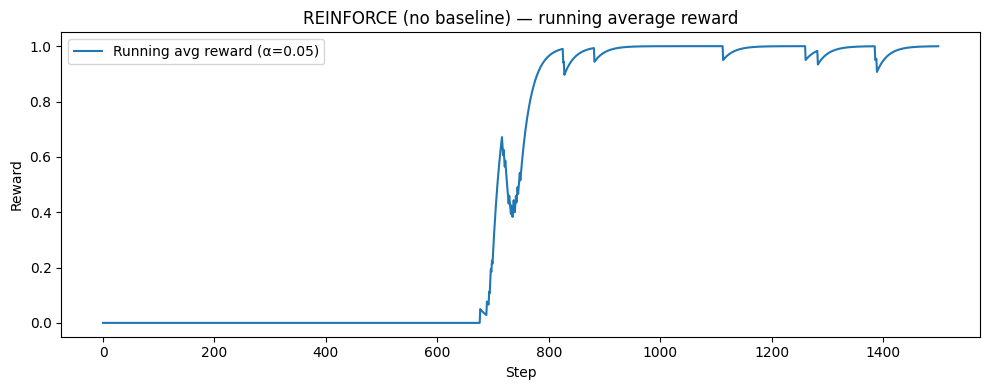

Final running avg reward: 0.9997


In [93]:
torch.manual_seed(42)
policy = CharPolicy(vocab_size=vocab_size)
optimizer = optim.Adam(policy.parameters(), lr=1e-2)

rewards_no_baseline: list[float] = []
running_avg: list[float] = []
alpha = 0.05  # smoothing factor for running average

for step in range(epochs):
    policy.train()
    seq, log_probs = sample(policy)
    R = reward(seq)

    # L(θ) = -R(τ) * Σ log π_θ(a_t | a_{<t})
    loss = -R * log_probs.sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    rewards_no_baseline.append(R)
    prev = running_avg[-1] if running_avg else 0.0
    running_avg.append(alpha * R + (1 - alpha) * prev)

# Plot running average reward
plt.figure(figsize=(10, 4))
plt.plot(running_avg, label='Running avg reward (α=0.05)')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('REINFORCE (no baseline) — running average reward')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Final running avg reward: {running_avg[-1]:.4f}")


Task 4b: REINFORCE with a running-mean baseline

In [94]:
torch.manual_seed(42)
model = CharPolicy(vocab_size=vocab_size)
optimizer = optim.Adam(model.parameters(), lr=1e-2)

rewards_with_baseline: list[float] = []
baseline = 0.0

for step in range(epochs):
    model.train()
    seq, log_probs = sample(model)
    R = reward(seq)

    advantage = R - baseline
    loss = -advantage * log_probs.sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Update EMA baseline after the gradient step
    baseline = 0.9 * baseline + 0.1 * R
    rewards_with_baseline.append(R)

# Plot both runs' moving averages on the same axes
window = 50
def moving_average(data: list[float], w: int) -> list[float]:
    return [
        sum(data[max(0, i - w):i + 1]) / len(data[max(0, i - w):i + 1])
        for i in range(len(data))
    ]

ma_no_baseline   = moving_average(rewards_no_baseline,   window)
ma_with_baseline = moving_average(rewards_with_baseline, window)


Wins (no baseline):   778 / 1500
Wins (with baseline): 801 / 1500


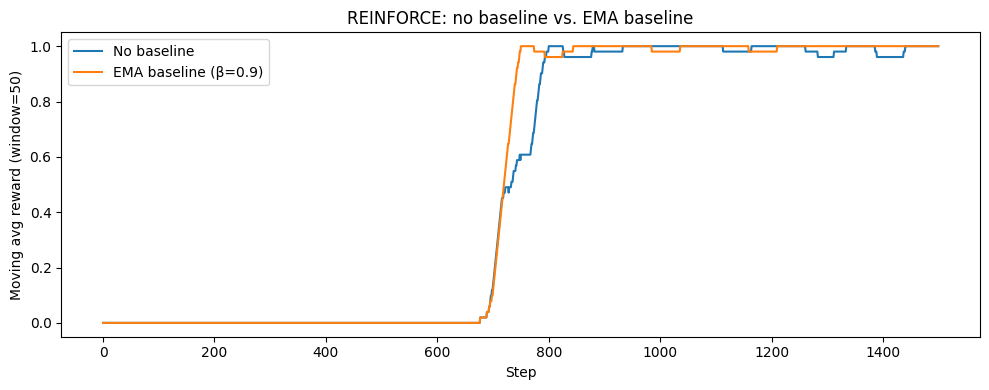

In [95]:
print(f"Wins (no baseline):   {sum(rewards_no_baseline):.0f} / {len(rewards_no_baseline)}")
print(f"Wins (with baseline): {sum(rewards_with_baseline):.0f} / {len(rewards_with_baseline)}")

plt.figure(figsize=(10, 4))
plt.plot(ma_no_baseline,   label='No baseline')
plt.plot(ma_with_baseline, label='EMA baseline (β=0.9)')
plt.xlabel('Step')
plt.ylabel(f'Moving avg reward (window={window})')
plt.title('REINFORCE: no baseline vs. EMA baseline')
plt.legend()
plt.tight_layout()
plt.show()


Task 5: Credit assignment analysis


5a. Inspect the learned conditional distributions

In [96]:
def reward_new(seq: list[str]) -> float:
    return 1.0 if seq[:4] == ['a', 'b', 'c', '<eos>'] else 0.0

In [97]:
# Inspect learned conditional distributions π(· | x)
model.eval()
with torch.no_grad():
    for ctx in ['<bos>', 'a', 'b', 'c']:
        x = torch.tensor([stoi[ctx]])
        probs = torch.softmax(model(x), dim=-1).squeeze()  # [vocab_size]
        dist_str = "  ".join(f"{itos[i]}:{probs[i].item():.3f}" for i in range(vocab_size))
        print(f"π(· | {ctx:5s}) :  {dist_str}")

# End-to-end verification: fraction of sampled trajectories that get reward_new = 1
n_samples = 200
wins = sum(reward_new(sample(model)[0]) for _ in range(n_samples))


π(· | <bos>) :  <bos>:0.035  a:0.951  b:0.014  c:0.000  <eos>:0.001
π(· | a    ) :  <bos>:0.000  a:0.009  b:0.991  c:0.000  <eos>:0.000
π(· | b    ) :  <bos>:0.000  a:0.001  b:0.000  c:0.999  <eos>:0.000
π(· | c    ) :  <bos>:0.223  a:0.670  b:0.069  c:0.019  <eos>:0.019


5b. Sample 10 trajectories from the trained model

In [98]:
model.eval()
for i in range(10):
    seq_i, _ = sample(model)
    R_i = reward_new(seq_i)
    print(f"[{i+1:2d}]  seq={seq_i}  R={R_i:.1f}")

[ 1]  seq=['a', 'b', 'c', 'a', 'b', 'c', 'a', 'b']  R=0.0
[ 2]  seq=['a', 'b', 'c', 'a', 'b', 'c', '<bos>', 'a']  R=0.0
[ 3]  seq=['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'a']  R=0.0
[ 4]  seq=['a', 'b', 'c', 'a', 'b', 'c', '<bos>', 'b']  R=0.0
[ 5]  seq=['a', 'b', 'c', 'a', 'b', 'c', 'a', 'b']  R=0.0
[ 6]  seq=['a', 'b', 'c', '<bos>', 'a', 'b', 'c', '<bos>']  R=0.0
[ 7]  seq=['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'b']  R=0.0
[ 8]  seq=['a', 'b', 'c', 'a', 'b', 'c', '<bos>', 'a']  R=0.0
[ 9]  seq=['a', 'b', 'c', 'a', 'b', 'c', 'b', 'c']  R=0.0
[10]  seq=['a', 'b', 'c', 'a', 'b', 'c', 'a', 'b']  R=0.0


5c. Discussion (3–5 sentences)

The reinforce loss for a single trajectory is 
L(θ)=−R(τ)⋅[logπ(a1 ∣ <bos>)+logπ(a2 ∣ a1)+logπ(a3 ∣ a2)+logπ(a4 ∣ a3)]

The term R(τ)⋅logπ(a1 ∣ <bos>) is an explicit addend in this sum. When loss.backward() runs, autograd differentiates through it and produces a gradient ∇θlogπ(a1 ∣ <bos> ), which is applied to the embedding and linear weights that produced the first-step logits — no time-travel required.

The reason this works despite the reward being terminal is that R(τ) is a scalar multiplier on the whole trajectory's log-probability. It doesn't flow backwards through time step by step; it simply scales every log-prob term in the loss by the same number. If the trajectory succeeded (R=1), every action — including a1 — is reinforced. If it failed (R=0), no parameters move at all.

This is the core credit-assignment mechanism of vanilla REINFORCE: the terminal reward is broadcast uniformly to all timesteps. It is unbiased in expectation, but high-variance in practice, because the first action receives identical gradient weight to the last, regardless of its actual causal contribution.

